# Exploratory Data Analysis

This notebook explores the main patterns in the credit card customer data before modelling.

The aim is to understand the target distribution and identify features that may be related to customer default.


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")

First, we examine the proportion of customers who defaulted and did not default.


In [28]:
(train["default"].value_counts(normalize=True) * 100).round(2)

default
0    77.88
1    22.12
Name: proportion, dtype: float64

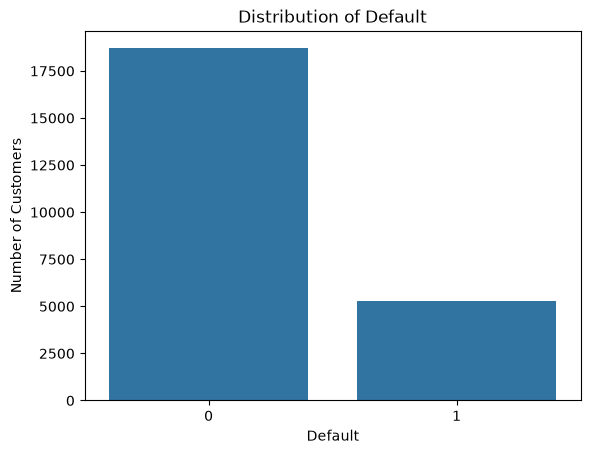

In [29]:
sns.countplot(x="default", data=train)

plt.title("Distribution of Default")
plt.xlabel("Default")
plt.ylabel("Number of Customers")

plt.show()


The target is moderately imbalanced. Around 77.88% of customers did not default, while 22.12% defaulted. Since the competition uses binary log loss, the model should focus on producing reliable default probabilities rather than only class predictions.


We look at the distributions of age and credit limit to get a basic understanding of the customer population.


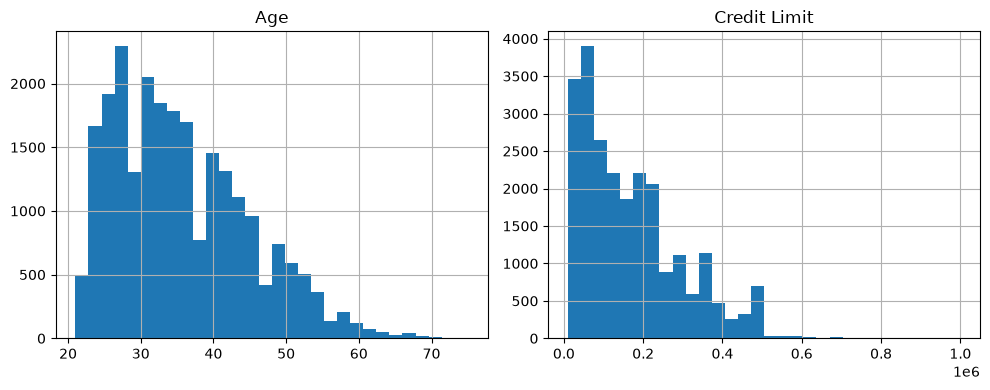

In [30]:
axes = train[["AGE", "LIMIT_BAL"]].hist(
    bins=30,
    figsize=(10, 4)
)

axes[0, 0].set_title("Age")
axes[0, 1].set_title("Credit Limit")

plt.tight_layout()
plt.show()


The distribution of credit limits is right-skewed. Most customers have lower credit limits, mainly below NT$200,000, while only a small number have very high credit limits.


Examine the correlation between numerical features and identify variables that may be related to default.


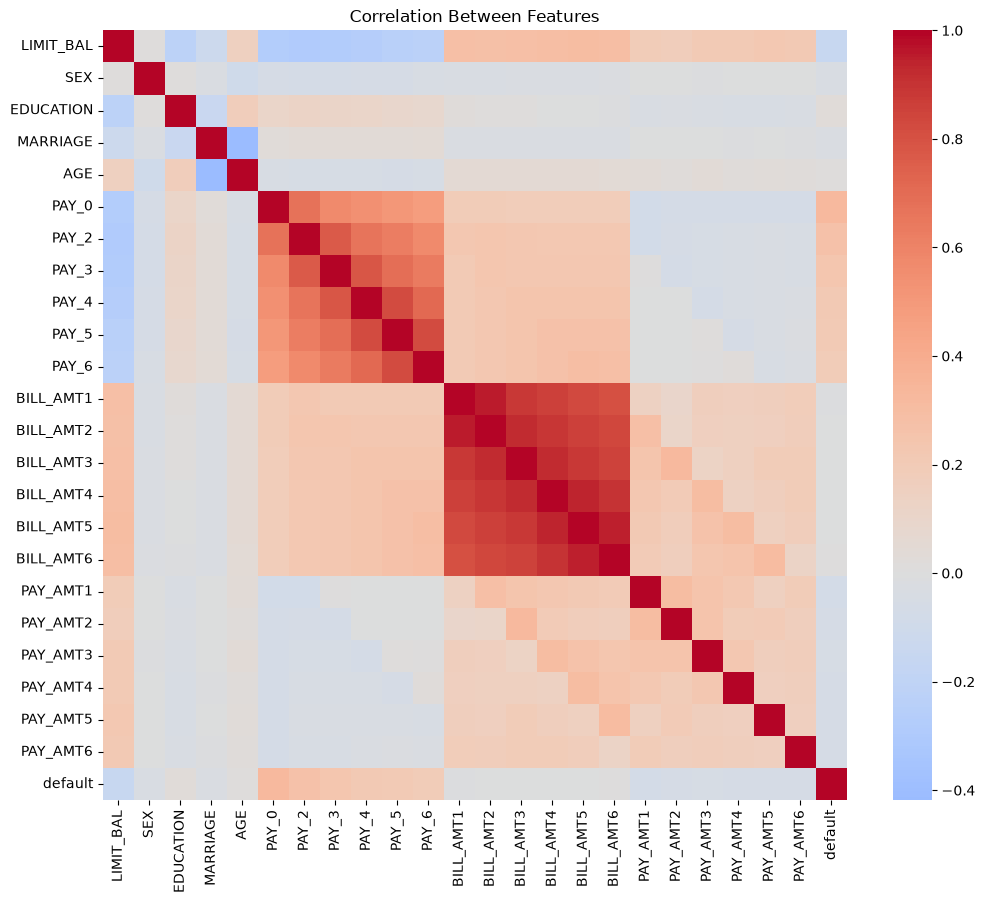

In [31]:
corr = train.drop(columns=["client_id"]).corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Features")
plt.show()


We compare credit limits between customers who defaulted and customers who did not.


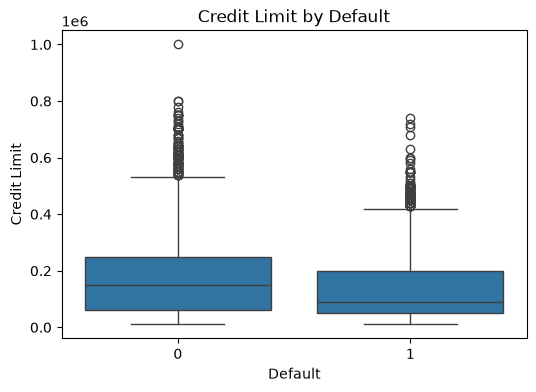

In [32]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    x="default",
    y="LIMIT_BAL",
    data=train
)

plt.title("Credit Limit by Default")
plt.xlabel("Default")
plt.ylabel("Credit Limit")

plt.show()


Group the credit limits to compare the observed default rate across different credit-limit ranges.


In [ ]:
limit_group = pd.cut(
    train["LIMIT_BAL"],
    bins=[
        0, 10000, 20000, 30000, 40000, 50000,
        100000, 200000, 300000, 500000, float("inf")
    ],
    labels=[
        "10k", "10-20k", "20-30k", "30-40k", "40-50k",
        "50-100k", "100-200k", "200-300k", "300-500k", "500k+"
    ]
)

train.groupby(limit_group, observed=False)["default"].agg(["count", "mean"])


,count,mean
LIMIT_BAL,,
10k,391,0.401535
10-20k,1594,0.360728
20-30k,1293,0.345708
30-40k,185,0.421622
40-50k,2686,0.255026
50-100k,3861,0.257964
100-200k,6279,0.195413
200-300k,4052,0.161895
300-500k,3493,0.133982


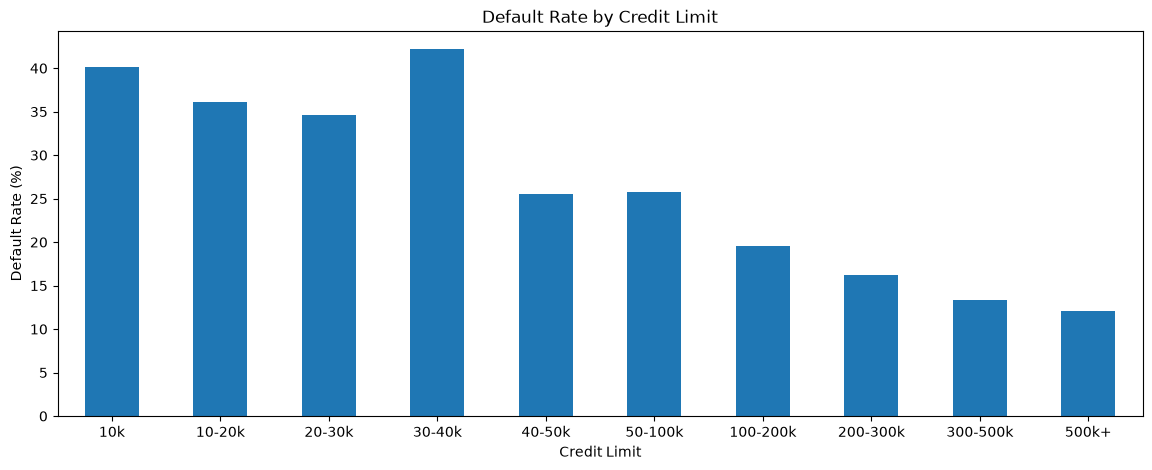

In [59]:
limit_default = (
    train.groupby(limit_group, observed=False)["default"]
    .mean()
    .mul(100)
)

limit_default.plot(kind="bar", figsize=(14, 5))

plt.title("Default Rate by Credit Limit")
plt.xlabel("Credit Limit")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.show()


The default rate generally decreases as the credit limit increases. Lower credit-limit groups have higher observed default rates, while customers with limits above NT$100,000 generally have lower default rates.


Compare default rates across the demographic variables.


In [60]:
for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    
    summary = (
        train.groupby(col)["default"]
        .agg(["count", "mean"])
        .reset_index()
    )

    summary.columns = [
        col,
        "Customer Count",
        "Default Rate (%)"
    ]

    summary["Default Rate (%)"] = (
        summary["Default Rate (%)"] * 100
    ).round(2)

    print(f"\n{col}")
    display(summary)



SEX


,SEX,Customer Count,Default Rate (%)
0,1,9557,23.96
1,2,14443,20.90



EDUCATION


,EDUCATION,Customer Count,Default Rate (%)
0,0,10,0.00
1,1,8551,19.41
2,2,11151,23.67
3,3,3911,25.11
4,4,97,6.19
5,5,237,6.33
6,6,43,16.28



MARRIAGE


,MARRIAGE,Customer Count,Default Rate (%)
0,0,42,11.90
1,1,11019,23.40
2,2,12685,20.97
3,3,254,25.98


The demographic variables show some differences in default rates, although the differences are smaller than the patterns seen in repayment behaviour.


We examine the most recent repayment status (`PAY_0`) to see how repayment behaviour differs between default and non-default customers.


In [36]:
pay0_default = (
    train.groupby("PAY_0")["default"]
    .mean()
    .mul(100)
)

pay0_default


PAY_0
-2    13.431504
-1    16.443762
 0    12.803476
 1    34.341033
 2    69.073125
 3    75.190840
 4    64.285714
 5    50.000000
 6    54.545455
 7    66.666667
 8    60.000000
Name: default, dtype: float64

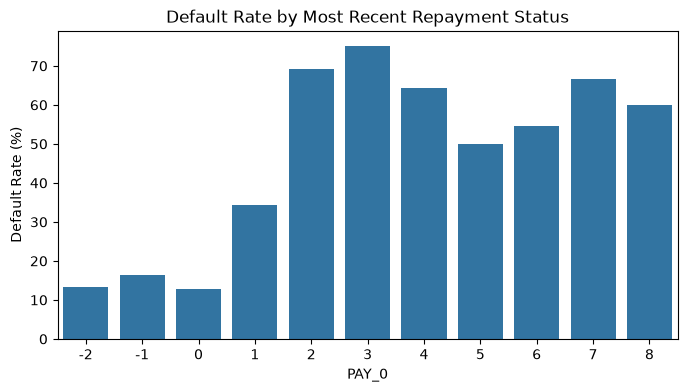

In [37]:
plt.figure(figsize=(8, 4))

sns.barplot(
    x=pay0_default.index,
    y=pay0_default.values
)

plt.title("Default Rate by Most Recent Repayment Status")
plt.xlabel("PAY_0")
plt.ylabel("Default Rate (%)")

plt.show()


Check the same relationship across the full repayment history.


In [38]:
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

for col in pay_cols:
    print(f"\n{col}")
    print(
        train.groupby(col)["default"]
        .mean()
        .round(3)
    )



PAY_0
PAY_0
-2    0.134
-1    0.164
 0    0.128
 1    0.343
 2    0.691
 3    0.752
 4    0.643
 5    0.500
 6    0.545
 7    0.667
 8    0.600
Name: default, dtype: float64

PAY_2
PAY_2
-2    0.184
-1    0.158
 0    0.159
 1    0.174
 2    0.556
 3    0.625
 4    0.526
 5    0.565
 6    0.667
 7    0.625
 8    0.000
Name: default, dtype: float64

PAY_3
PAY_3
-2    0.184
-1    0.155
 0    0.173
 1    0.250
 2    0.520
 3    0.594
 4    0.578
 5    0.500
 6    0.632
 7    0.857
 8    0.667
Name: default, dtype: float64

PAY_4
PAY_4
-2    0.189
-1    0.159
 0    0.184
 1    0.500
 2    0.523
 3    0.625
 4    0.642
 5    0.571
 6    0.250
 7    0.822
 8    0.500
Name: default, dtype: float64

PAY_5
PAY_5
-2    0.193
-1    0.159
 0    0.190
 2    0.544
 3    0.611
 4    0.615
 5    0.667
 6    0.750
 7    0.818
 8    1.000
Name: default, dtype: float64

PAY_6
PAY_6
-2    0.199
-1    0.166
 0    0.189
 2    0.510
 3    0.650
 4    0.628
 5    0.545
 6    0.722
 7    0.824
 8    1.000
Name

Repayment-status variables show a strong relationship with default risk. For example, the observed default rate for `PAY_0` rises substantially as repayment delays increase. Similar patterns appear across the other repayment-status variables.


In [39]:
bill_cols = [
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"
]

train[bill_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
BILL_AMT1,24000.0,51190.568667,73864.760063,-165580.0,3481.75,22435.5,67002.50,964511.0
BILL_AMT2,24000.0,49051.114833,71235.885503,-69777.0,2935.00,21190.5,63635.00,983931.0
BILL_AMT3,24000.0,46859.046750,69551.171536,-157264.0,2570.50,20010.5,59857.00,1664089.0
BILL_AMT4,24000.0,43175.799292,64534.910992,-65167.0,2300.75,18932.0,54341.50,891586.0
BILL_AMT5,24000.0,40271.754333,60980.478739,-61372.0,1710.25,18021.5,49937.50,927171.0
BILL_AMT6,24000.0,38743.087125,59707.335820,-209051.0,1206.00,16926.5,48904.75,961664.0


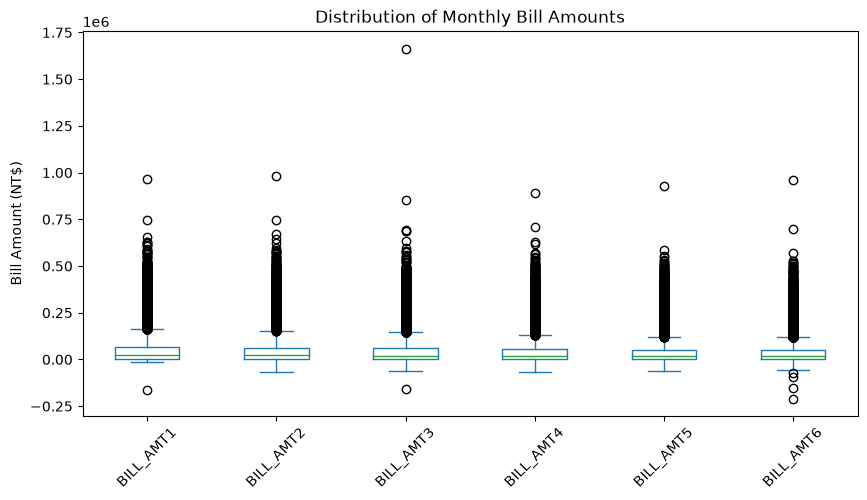

In [40]:
train[bill_cols].plot(
    kind="box",
    figsize=(10, 5)
)

plt.title("Distribution of Monthly Bill Amounts")
plt.ylabel("Bill Amount (NT$)")
plt.xticks(rotation=45)

plt.show()


In [41]:
bill_group = pd.cut(
    train["BILL_AMT1"],
    bins=[-float("inf"), 0, 10000, 50000, 100000, 200000, float("inf")],
    labels=["≤0", "0-10k", "10-50k", "50-100k", "100-200k", "200k+"]
)

train.groupby(
    bill_group,
    observed=False
)["default"].agg(["count", "mean"])


,count,mean
BILL_AMT1,,
≤0,2111,0.249171
0-10k,6578,0.211614
10-50k,7740,0.235271
50-100k,3665,0.214734
100-200k,2691,0.193980
200k+,1215,0.214815


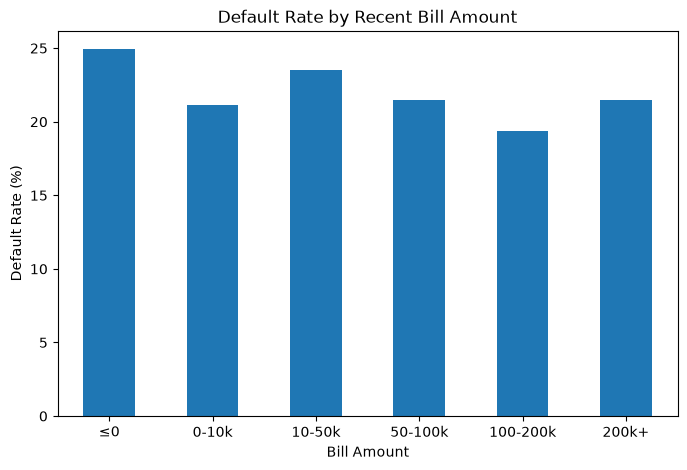

In [42]:
bill_default = (
    train.groupby(bill_group, observed=False)["default"]
    .mean()
    .mul(100)
)

bill_default.plot(kind="bar", figsize=(8, 5))

plt.title("Default Rate by Recent Bill Amount")
plt.xlabel("Bill Amount")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.show()


Bill amounts have a wide range and many extreme values, but the grouped default rates do not show as strong a pattern as repayment status.


Look at previous payment amounts and compare recent payment amounts with default.


In [43]:
payment_cols = [
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

train[payment_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
PAY_AMT1,24000.0,5711.710125,17155.309436,0.0,992.50,2100.0,5004.00,873552.0
PAY_AMT2,24000.0,5955.190125,24350.211213,0.0,780.00,2000.0,5000.00,1684259.0
PAY_AMT3,24000.0,5262.745792,18426.028570,0.0,390.00,1800.0,4500.00,896040.0
PAY_AMT4,24000.0,4853.362792,15752.040523,0.0,298.75,1500.0,4001.25,621000.0
PAY_AMT5,24000.0,4749.935125,14873.057360,0.0,212.75,1500.0,4005.00,417990.0
PAY_AMT6,24000.0,5161.937458,17925.431411,0.0,100.00,1500.0,4000.00,528666.0


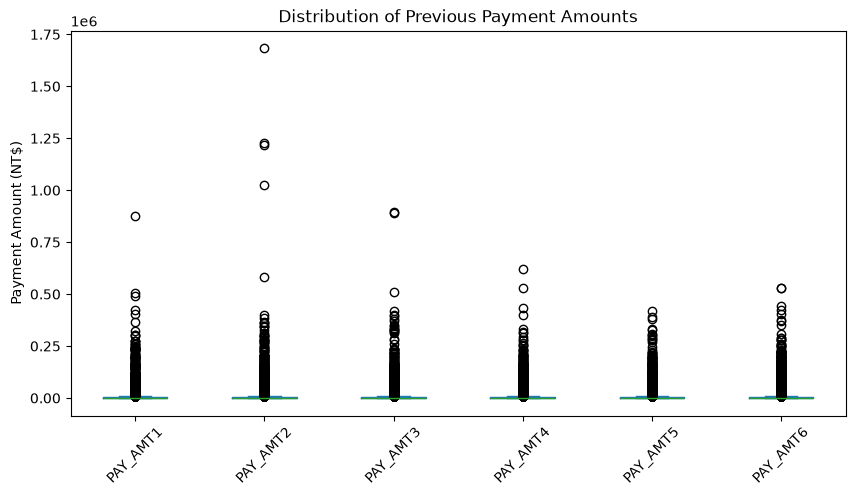

In [44]:
train[payment_cols].plot(
    kind="box",
    figsize=(10, 5)
)

plt.title("Distribution of Previous Payment Amounts")
plt.ylabel("Payment Amount (NT$)")
plt.xticks(rotation=45)

plt.show()


In [45]:
payment_group = pd.cut(
    train["PAY_AMT1"],
    bins=[-float("inf"), 0, 5000, 10000, 30000, 50000, 100000, float("inf")],
    labels=["0", "0-5k", "5-10k", "10-30k", "30-50k", "50-100k", "100k+"]
)

train.groupby(
    payment_group,
    observed=False
)["default"].agg(["count", "mean"])


,count,mean
PAY_AMT1,,
0,4223,0.355435
0-5k,13752,0.214151
5-10k,3406,0.155021
10-30k,1950,0.144103
30-50k,289,0.083045
50-100k,256,0.085938
100k+,124,0.064516


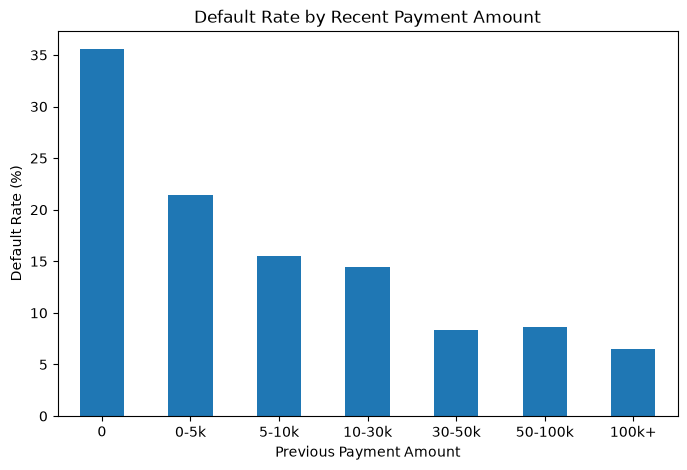

In [46]:
payment_default = (
    train.groupby(payment_group, observed=False)["default"]
    .mean()
    .mul(100)
)

payment_default.plot(kind="bar", figsize=(8, 5))

plt.title("Default Rate by Recent Payment Amount")
plt.xlabel("Previous Payment Amount")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.show()


Previous payment amount shows a clear association with default risk. Customers with lower recent payment amounts generally have higher observed default rates, while larger previous payments are associated with lower default rates.
